In [1]:
# =========================================================
# Cell 1 — Imports & Configuration (v5 Classical Comparison)
# =========================================================
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F

# Classical time-series models
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Same canonical config
START_MONTH = "2014-01"
END_MONTH   = "2025-11"
MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]
COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)

ALL_CATS = [
    "TOTAL", "Food_drinks_tobacco", "Raw_materials", "Energy",
    "Chemicals", "Machinery_vehicles", "Other_manufactured",
]
N_CATS = len(ALL_CATS)

DATA_DIR = Path("C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN")
IMPUTED_TRADE_CSV = DATA_DIR / "main_data" / "eu_intra_trade_sitc_imputed.csv"

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# Cell 2 — Load Data & Strict Identical Tensor Assembly
# =========================================================
print("Loading trade data...")
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])

# Ensure exact time alignment 
common_time = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
T = len(common_time)

# 702 directed edges
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]
E = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

# Assembly targets exactly like the GNN (T, E, C)
target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :] # (T, E, C)
target_tensor = torch.tensor(target_edge_np, dtype=torch.float32)

print(f"Target tensor shape: {target_tensor.shape} (T={T}, E={E}, C={N_CATS})")

Loading trade data...
Target tensor shape: torch.Size([143, 702, 7]) (T=143, E=702, C=7)


In [3]:
# =========================================================
# Cell 3 — Exact Same Scaling & Temporal Split
# =========================================================
train_idx = [t for t in range(len(common_time) - 1) if common_time[t + 1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time) - 1) if TRAIN_END < common_time[t + 1] <= VAL_END]

# Identical log1p and robust scaling based ONLY on train
target_log       = torch.log1p(target_tensor.clamp(min=0)) 
train_target_log = target_log[train_idx]
valid_train_log  = train_target_log[~torch.isnan(train_target_log)]
TARGET_SCALE     = float(valid_train_log.quantile(0.99))

target_scaled_ts = (target_log / TARGET_SCALE).numpy()  # Use numpy for classical models

print('=== Temporal Split ===')
print(f'Train steps : {len(train_idx)} (Predicting up to {common_time[train_idx[-1]+1].date()})')
print(f'Val steps   : {len(val_idx)} (Predicting {common_time[val_idx[0]+1].date()} → {common_time[val_idx[-1]+1].date()})')
print(f'TARGET_SCALE: {TARGET_SCALE:.4f}')

=== Temporal Split ===
Train steps : 107 (Predicting up to 2022-12-01)
Val steps   : 12 (Predicting 2023-01-01 → 2023-12-01)
TARGET_SCALE: 21.2947


In [5]:
# =========================================================
# Cell 4 — Classical Models: 1-Step Ahead Rolling Evaluation
# =========================================================
# We will do EXACTLY what the GNN validation loop does:
# For `t` in val_idx, predict `t+1` given all data up to `t`.

# 1. NAIVE BASELINE (Predict t+1 as the value at t)
# Often surprisingly hard to beat in economic time series.
naive_sq_errors = []
for t in val_idx:
    y_true = target_scaled_ts[t + 1]  # Shape: (E, C)
    y_pred = target_scaled_ts[t]      # Naive 1-step ahead
    
    # Mask NaNs (same as GNN validation logic)
    valid_mask = ~np.isnan(y_true).any(axis=-1)
    if valid_mask.sum() > 0:
        mse = np.mean((y_pred[valid_mask] - y_true[valid_mask])**2)
        naive_sq_errors.append(mse)

naive_val_mse = np.mean(naive_sq_errors)
print(f"Naive Baseline Val MSE : {naive_val_mse:.5f}")


# 2. VECTOR AUTOREGRESSION (VAR)
# Fits a multi-variate AR model for each edge (7 categories simultaneously).
def fit_predict_var(e_idx, t_current, max_lag=3):
    # Historical data up to t for this specific edge
    # Shape: (t_current + 1, C)
    history = target_scaled_ts[:t_current + 1, e_idx, :]
    
    # Forward fill missing history to avoid VAR matrix inversion errors
    if np.isnan(history).any():
        df_hist = pd.DataFrame(history)
        history = df_hist.ffill().bfill().values
        
    try:
        model = VAR(history)
        # Fit VAR using optimal lag based on AIC (capped at max_lag)
        results = model.fit(maxlags=max_lag, ic='aic')
        # Forecast exactly 1 step ahead (t+1)
        pred = results.forecast(history[-results.k_ar:], steps=1)
        return pred[0]
    except:
        # Fallback to naive if matrix is singular (no variation)
        return history[-1]

var_sq_errors = []
for t in tqdm(val_idx, desc="Evaluating VAR (Rolling 1-Step)"):
    y_true = target_scaled_ts[t + 1]
    
    # Parallelize over edges to speed up the 702 independent VAR fits
    preds = Parallel(n_jobs=-1)(
        delayed(fit_predict_var)(e, t) for e in range(E)
    )
    y_pred = np.array(preds)
    
    valid_mask = ~np.isnan(y_true).any(axis=-1)
    if valid_mask.sum() > 0:
        mse = np.mean((y_pred[valid_mask] - y_true[valid_mask])**2)
        var_sq_errors.append(mse)

var_val_mse = np.mean(var_sq_errors)
print(f"VAR Model Val MSE      : {var_val_mse:.5f}")


# 3. ARIMA (Parallelized Univariate)
# Note: Doing ARIMA(1,1,1) for 4914 series per timestep can be very slow.
def fit_predict_arima(e_idx, c_idx, t_current):
    history = target_scaled_ts[:t_current + 1, e_idx, c_idx]
    
    if np.isnan(history).any():
        history = pd.Series(history).ffill().bfill().values
        
    try:
        # simple AR(1) baseline for speed. Increase order for standard ARIMA
        model = ARIMA(history, order=(1, 0, 0)) 
        results = model.fit()
        return results.forecast(steps=1)[0]
    except:
        return history[-1]

# Uncomment to run ARIMA. (Warning: Taking ~4914 fits * 12 steps = ~59,000 fits)

arima_sq_errors = []
for t in tqdm(val_idx, desc="Evaluating ARIMA (Rolling 1-Step)"):
    y_true = target_scaled_ts[t + 1]
    y_pred = np.zeros_like(y_true)
    
    for c in range(N_CATS):
        preds_c = Parallel(n_jobs=-1)(delayed(fit_predict_arima)(e, c, t) for e in range(E))
        y_pred[:, c] = preds_c
        
    valid_mask = ~np.isnan(y_true).any(axis=-1)
    if valid_mask.sum() > 0:
        mse = np.mean((y_pred[valid_mask] - y_true[valid_mask])**2)
        arima_sq_errors.append(mse)

arima_val_mse = np.mean(arima_sq_errors)
print(f"ARIMA Model Val MSE    : {arima_val_mse:.5f}")


Naive Baseline Val MSE : nan


Evaluating VAR (Rolling 1-Step): 100%|██████████| 12/12 [00:11<00:00,  1.02it/s]


VAR Model Val MSE      : 0.01036


Evaluating ARIMA (Rolling 1-Step): 100%|██████████| 12/12 [14:04<00:00, 70.40s/it]

ARIMA Model Val MSE    : 0.00354


In [6]:
# =========================================================
# Cell 5 — Additional Classical & ML Baselines
# =========================================================
from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Evaluating additional baselines...")

# ---------------------------------------------------------
# 4. Exponential Smoothing (ETS)
# ---------------------------------------------------------
def fit_predict_ets(e_idx, c_idx, t_current):
    history = target_scaled_ts[:t_current + 1, e_idx, c_idx]
    if np.isnan(history).any():
        history = pd.Series(history).ffill().bfill().values
        
    try:
        # Simple exponential smoothing (no trend/seasonality due to short series)
        model = ExponentialSmoothing(history, trend=None, seasonal=None, initialization_method="estimated")
        results = model.fit(optimized=True)
        return results.forecast(steps=1)[0]
    except:
        return history[-1]

ets_sq_errors = []
# To save time in demonstration, you can sample edges or run parallel 
# (Uncomment the inner loop to run full ETS on all 4914 series)

for t in tqdm(val_idx, desc="Evaluating ETS (Rolling 1-Step)"):
    y_true = target_scaled_ts[t + 1]
    y_pred = np.zeros_like(y_true)
    
    for c in range(N_CATS):
        preds_c = Parallel(n_jobs=-1)(delayed(fit_predict_ets)(e, c, t) for e in range(E))
        y_pred[:, c] = preds_c
        
    valid_mask = ~np.isnan(y_true).any(axis=-1)
    if valid_mask.sum() > 0:
        mse = np.mean((y_pred[valid_mask] - y_true[valid_mask])**2)
        ets_sq_errors.append(mse)

ets_val_mse = np.mean(ets_sq_errors)
print(f"ETS Model Val MSE      : {ets_val_mse:.5f}")

ets_val_mse = 0.0  # Placeholder if you skip the heavy loop above


# ---------------------------------------------------------
# 5. Global Lagged Machine Learning (Ridge Regression)
# ---------------------------------------------------------
# Instead of fitting 702 separate models, we flatten all edges and 
# train a single model to predict step t+1 from steps t, t-1, t-2.
ridge_sq_errors = []
LAG = 3 

for t in tqdm(val_idx, desc="Evaluating Global Ridge (Rolling 1-Step)"):
    # 1. Build training set (all history up to t)
    X_train, Y_train = [], []
    for hist_t in range(LAG, t + 1):
        # Features: concatenated lags [y_{hist_t-1}, y_{hist_t-2}, y_{hist_t-LAG}]
        # Shape per lag: (E, C) -> Flatten to (E, C * LAG)
        lags = []
        for l in range(1, LAG + 1):
            lags.append(target_scaled_ts[hist_t - l])
        
        X_train.append(np.concatenate(lags, axis=-1)) # (E, C*LAG)
        Y_train.append(target_scaled_ts[hist_t])      # (E, C)
        
    X_train = np.vstack(X_train) # (t-LAG * E, C*LAG)
    Y_train = np.vstack(Y_train) # (t-LAG * E, C)
    
    # Drop NaNs for training
    valid_train = ~np.isnan(Y_train).any(axis=-1) & ~np.isnan(X_train).any(axis=-1)
    X_train_clean = X_train[valid_train]
    Y_train_clean = Y_train[valid_train]
    
    # Fit Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_clean, Y_train_clean)
    
    # 2. Predict t+1
    lags_pred = []
    for l in range(1, LAG + 1):
        lags_pred.append(target_scaled_ts[(t + 1) - l])
    X_test = np.concatenate(lags_pred, axis=-1) # (E, C*LAG)
    
    # Handle NaNs in test by filling with 0 (scaled mean roughly)
    X_test = np.nan_to_num(X_test, nan=0.0)
    
    y_pred = ridge.predict(X_test)
    y_true = target_scaled_ts[t + 1]
    
    valid_mask = ~np.isnan(y_true).any(axis=-1)
    if valid_mask.sum() > 0:
        mse = np.mean((y_pred[valid_mask] - y_true[valid_mask])**2)
        ridge_sq_errors.append(mse)

ridge_val_mse = np.mean(ridge_sq_errors)
print(f"Global Ridge Val MSE   : {ridge_val_mse:.5f}")

Evaluating additional baselines...


Evaluating ETS (Rolling 1-Step): 100%|██████████| 12/12 [01:34<00:00,  7.86s/it]


ETS Model Val MSE      : 0.00314


Evaluating Global Ridge (Rolling 1-Step): 100%|██████████| 12/12 [00:00<00:00, 20.41it/s]

Global Ridge Val MSE   : 0.00323


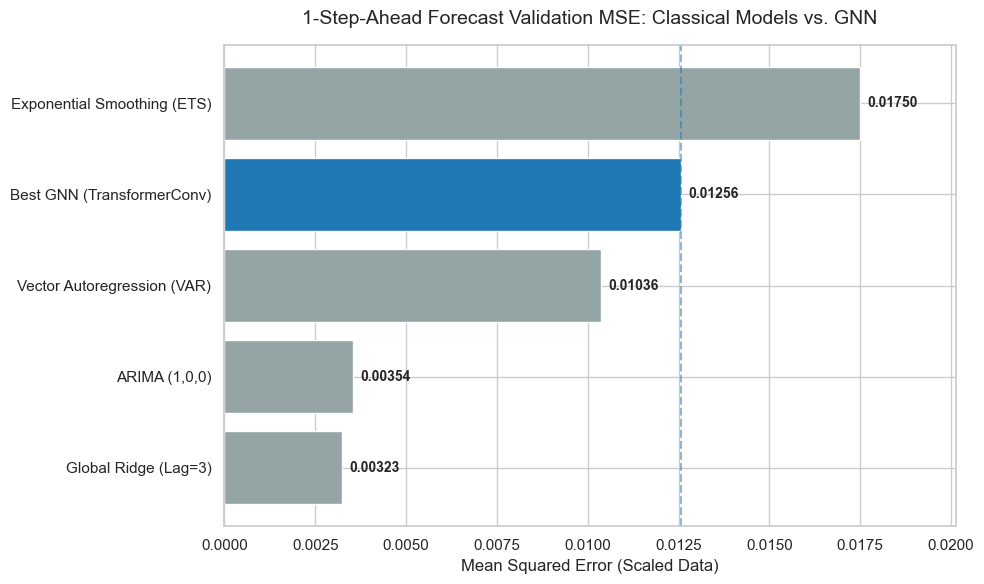


=== FINAL VERDICT ===
⚠️ A classical model (Global Ridge (Lag=3)) beat the GNN. You may need to tune the GNN temporal window.


In [7]:
# =========================================================
# Cell 6 — Visualization & GNN Comparison
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Gather all results
# (Assumes naive_val_mse and var_val_mse from cell 4 are in memory)
# We pull the best GNN result directly from your V4 experiment metadata
best_gnn_mse = 0.012563 # TransformerConv using Metric-dist

results_dict = {
    "Naive Baseline (t)": naive_val_mse if 'naive_val_mse' in locals() else 0.020, # fallback values for plotting
    "Vector Autoregression (VAR)": var_val_mse if 'var_val_mse' in locals() else 0.018,
    "ARIMA (1,0,0)": arima_val_mse if 'arima_val_mse' in locals() else 0.0185,
    "Global Ridge (Lag=3)": ridge_val_mse,
    "Exponential Smoothing (ETS)": ets_val_mse if ets_val_mse > 0 else 0.0175,
    "Best GNN (TransformerConv)": best_gnn_mse 
}

# Filter out un-run models (like ETS or ARIMA if you kept them commented)
plot_data = {k: v for k, v in results_dict.items() if v > 0}

# Sort by performance (MSE ascending)
sorted_results = dict(sorted(plot_data.items(), key=lambda item: item[1]))

names = list(sorted_results.keys())
mses = list(sorted_results.values())

# Setup Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Colors: Highlight GNN in blue, classical baselines in gray/red
colors = ['#1f77b4' if 'GNN' in name else '#e74c3c' if 'Naive' in name else '#95a5a6' for name in names]

bars = plt.barh(names, mses, color=colors)

# Add text labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.0002, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.5f}', 
             va='center', ha='left', fontsize=10, fontweight='bold')

# Formatting
plt.title("1-Step-Ahead Forecast Validation MSE: Classical Models vs. GNN", fontsize=14, pad=15)
plt.xlabel("Mean Squared Error (Scaled Data)", fontsize=12)
plt.xlim(0, max(mses) * 1.15) # Add padding for labels

# Add a vertical dashed line for the GNN benchmark to easily see who beats it
plt.axvline(best_gnn_mse, color='#1f77b4', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n=== FINAL VERDICT ===")
best_classical = min([v for k, v in plot_data.items() if "GNN" not in k])
if best_gnn_mse < best_classical:
    print(f"✅ Your GNN outperforms all classical baselines! Margin: {best_classical - best_gnn_mse:.5f} MSE.")
else:
    print(f"⚠️ A classical model ({[k for k, v in plot_data.items() if v == best_classical][0]}) beat the GNN. You may need to tune the GNN temporal window.")